#Association Rule Mining on Educational Data

 Mining association rules from the preprocessed KDD Cup 2010 Educational Data Mining Challenge dataset using weighted Apriori algorithm


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [5]:
#load preprocessed dataset
file_path = './data/processed/final_preprocessed.csv'
df = pd.read_csv(file_path, header=[0,1])
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1877, 49)


KC(Default)                                                            \
      Missing Entering_a_given Using_simple_numbers Using_small_numbers   
0           0                1                    0                   0   
1           1                0                    0                   0   
2           0                0                    1                   1   
3           0                0                    0                   1   
4           1                0                    0                   0   

                                                    Problem Hierarchy  \
  Identifying_units Problem Hierarchy_Unit CTA1_08, Section CTA1_08-3   
0                 0                                                 0   
1                 0                                                 0   
2                 0                                                 0   
3                 0                                                 0   
4                 0                                                 0   

                                                     \
  Problem Hierarchy_Unit CTA1_13, Section CTA1_13-1   
0                                                 0   
1                                                 0   
2                                                 0   
3                                                 1   
4                                                 0   

                                                     \
  Problem Hierarchy_Unit CTA1_01, Section CTA1_01-3   
0                                                 0   
1                                                 1   
2                                                 0   
3                                                 0   
4                                                 0   

                                                     \
  Problem Hierarchy_Unit CTA1_02, Section CTA1_02-4   
0                                                 0   
1                                                 0   
2                                                 0   
3                                                 0   
4                                                 0   

                                                         Problem Name  \
  Problem Hierarchy_Unit CTA1_06, Section CTA1_06-4 Problem Name_EG44   
0                                                 0                 0   
1                                                 0                 0   
2                                                 0                 0   
3                                                 0                 0   
4                                                 0                 1   

                                                             \
  Problem Name_NOV13 Problem Name_REAL28 Problem Name_DEC04   
0                  0                   0                  0   
1                  0                   0                  0   
2                  0                   0                  0   
3                  0                   0                  0   
4                  0                   0                  0   

                           Step Name                                \
  Problem Name_PROP01 Step Name_R3C2 Step Name_R1C1 Step Name_R3C1   
0                   0              0              0              0   
1                   0              0              1              0   
2                   0              0              0              0   
3                   0              0              0              0   
4                   0              0              0              0   

                                Problem View                       Corrects  \
  Step Name_R5C1 Step Name_R4C1          Low Medium High Very_High      Few   
0              0              0            1      0    0         0        1   
1              0              0            1      0    0         0        1   
2              0              0            1 

In [6]:
df.columns.get_level_values(0)

Index(['KC(Default)', 'KC(Default)', 'KC(Default)', 'KC(Default)',
       'KC(Default)', 'Problem Hierarchy', 'Problem Hierarchy',
       'Problem Hierarchy', 'Problem Hierarchy', 'Problem Hierarchy',
       'Problem Name', 'Problem Name', 'Problem Name', 'Problem Name',
       'Problem Name', 'Step Name', 'Step Name', 'Step Name', 'Step Name',
       'Step Name', 'Problem View', 'Problem View', 'Problem View',
       'Problem View', 'Corrects', 'Corrects', 'Incorrects', 'Incorrects',
       'Hints', 'Hints', 'Opportunity(Default)', 'Opportunity(Default)',
       'Opportunity(Default)', 'Opportunity(Default)', 'Opportunity(Default)',
       'Step Duration (sec)', 'Step Duration (sec)', 'Step Duration (sec)',
       'Step Duration (sec)', 'Step Duration (sec)',
       'Correct Step Duration (sec)', 'Correct Step Duration (sec)',
       'Correct Step Duration (sec)', 'Correct Step Duration (sec)',
       'Correct Step Duration (sec)', 'Error Step Duration (sec)',
       'Error Step Durat

##1. Define item weights for weighted apriori

In [ ]:
print("="*80)
print("DEFINING ITEM WEIGHTS FOR WEIGHTED APRIORI")
print("="*80)

# Weight assignment strategy (based on educational domain knowledge):
# 1. Struggle indicators (HIGH weight) - important to detect at-risk patterns
# 2. Success indicators (MEDIUM-HIGH weight) - important for best practices
# 3. Knowledge components (MEDIUM weight) - domain-specific importance
# 4. Engagement patterns (MEDIUM weight) - behavioral indicators
# 5. Neutral/contextual features (LOW weight) - supportive information

item_weights = {}

# ============================================================================
# 1. STRUGGLE INDICATORS (Weight: 2.5 - 3.0)
# ============================================================================
# High importance: patterns indicating student difficulty
print("\n1. Assigning weights to STRUGGLE INDICATORS...")

# Many errors/hints indicate struggle
item_weights['Incorrects_Binned=Many'] = 3.0
item_weights['Hints_Binned=Many'] = 2.5

# Long error durations suggest prolonged difficulty
item_weights['Error_Step_Duration_Binned=ESD_15'] = 2.0
item_weights['Error_Step_Duration_Binned=ESD_14'] = 1.8
item_weights['Error_Step_Duration_Binned=ESD_13'] = 1.6

# First attempt incorrect
item_weights['Correct First Attempt=0'] = 2.2

# Low engagement (early dropout risk)
item_weights['Engagement_Level_Binned=Light'] = 2.0

print(f"   Assigned {len([k for k in item_weights if 'Incorrect' in k or 'Hints' in k or 'Error' in k or 'Light' in k])} struggle-related weights")

# ============================================================================
# 2. SUCCESS INDICATORS (Weight: 1.5 - 2.0)
# ============================================================================
print("\n2. Assigning weights to SUCCESS INDICATORS...")

# Few errors/hints indicate mastery
item_weights['Incorrects_Binned=Few'] = 1.5
item_weights['Hints_Binned=Few'] = 1.5
item_weights['Corrects_Binned=Many'] = 1.8

# First attempt correct
item_weights['Correct First Attempt=1'] = 1.8

# High engagement (persistence)
item_weights['Engagement_Level_Binned=Very_Heavy'] = 1.7
item_weights['Engagement_Level_Binned=Heavy'] = 1.5

print(f"   Assigned {len([k for k in item_weights if 'Few' in k or 'Many' in k or 'Correct First Attempt=1' in k or 'Heavy' in k])} success-related weights")

# ============================================================================
# 3. KNOWLEDGE COMPONENTS (Weight: 1.3 - 2.0)
# ============================================================================
print("\n3. Assigning weights to KEY KNOWLEDGE COMPONENTS...")

# TODO: Alter, hard coding is not a good idea
# Core algebraic skills (high educational value)
important_kcs = {
    'KC_Entering_a_given': 1.8,
    'KC_Define_Variable': 1.7,
    'KC_Entering_the_slope': 1.6,
    'KC_Entering_the_y_intercept': 1.6,
    'KC_Setting_the_slope': 1.5,
    'KC_Setting_the_y_intercept': 1.5,
}

# SkillRule KCs (procedural knowledge - very important)
skillrule_weight = 1.8
kc_cols = [col for col in ['KC_[SkillRule:_Add/Subtract;_[Typein_Skill:_{Isolate_positive;_Isolate_negative;_Remove_constant;_Consolidate_vars,_no_coeff;_Consolidate_vars_with_coeff;_Consolidate_vars,_any}]]',
                            'KC_[SkillRule:_Multiply/Divide;_[Typein_Skill:_{Remove_coefficient;_Variable_in_denominator}]]',
                            'KC_[SkillRule:_Remove_constant;_{ax+b=c,_positive;_ax+b=c,_negative;_x+a=b,_positive;_x+a=b,_negative;_[var_expr]+[const_expr]=[const_expr],_positive;_[var_expr]+[const_expr]=[const_expr],_negative;_[var_expr]+[const_expr]=[const_expr],_all;_Combine_constants_to_right;_Combine_constants_to_left;_a_x=b,_positive;_a/x+b=c,_positive;_a/x+b=c,_negative}]']]

for kc in important_kcs:
    item_weights[f'{kc}=1'] = important_kcs[kc]

# All other KCs get default weight
item_weights['KC_default'] = 1.3

print(f"   Assigned {len(important_kcs)} high-priority KC weights")
print(f"   Other KCs will use default weight: 1.3")

# ============================================================================
# 4. TIME/DURATION PATTERNS (Weight: 1.2 - 1.5)
# ============================================================================
print("\n4. Assigning weights to DURATION PATTERNS...")

# Extreme durations (very quick or very slow) may indicate issues
item_weights['Step_Duration_Binned=SD_1'] = 1.3  # Very quick (possibly guessing)
item_weights['Step_Duration_Binned=SD_15'] = 1.4  # Very slow (struggling)

# Correct step durations
item_weights['Correct_Step_Duration_Binned=CSD_1'] = 1.2
item_weights['Correct_Step_Duration_Binned=CSD_15'] = 1.2

print(f"   Assigned duration-based weights")

# ============================================================================
# 5. CONTEXTUAL FEATURES (Weight: 1.0)
# ============================================================================
print("\n5. Setting DEFAULT weight for other items...")

# Default weight for all other items
item_weights['default'] = 1.0

print(f"   Default weight: 1.0")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("WEIGHT ASSIGNMENT SUMMARY")
print("="*80)
print(f"Total explicit weights defined: {len(item_weights)}")
print(f"\nWeight distribution:")
print(f"   High priority (≥2.0):   {len([w for w in item_weights.values() if w >= 2.0])} items")
print(f"   Medium priority (1.5-2.0): {len([w for w in item_weights.values() if 1.5 <= w < 2.0])} items")
print(f"   Low priority (<1.5):    {len([w for w in item_weights.values() if w < 1.5])} items")

print("\n" + "="*80)
print("Sample weights:")
for item, weight in list(item_weights.items())[:15]:
    print(f"   {item:50s} → {weight}")
print("   ...")

DEFINING ITEM WEIGHTS FOR WEIGHTED APRIORI

1. Assigning weights to STRUGGLE INDICATORS...
   Assigned 6 struggle-related weights

2. Assigning weights to SUCCESS INDICATORS...
   Assigned 8 success-related weights

3. Assigning weights to KEY KNOWLEDGE COMPONENTS...
   Assigned 6 high-priority KC weights
   Other KCs will use default weight: 1.3

4. Assigning weights to DURATION PATTERNS...
   Assigned duration-based weights

5. Setting DEFAULT weight for other items...
   Default weight: 1.0

WEIGHT ASSIGNMENT SUMMARY
Total explicit weights defined: 25

Weight distribution:
   High priority (≥2.0):   5 items
   Medium priority (1.5-2.0): 14 items
   Low priority (<1.5):    6 items

Sample weights:
   Incorrects_Binned=Many                             → 3.0
   Hints_Binned=Many                                  → 2.5
   Error_Step_Duration_Binned=ESD_15                  → 2.0
   Error_Step_Duration_Binned=ESD_14                  → 1.8
   Error_Step_Duration_Binned=ESD_13               

##2. Convert Categorical Binned Columns to One-Hot Encoded Binary Columns

In [7]:
print("="*80)
print("DEFINING ITEM WEIGHTS FOR WEIGHTED APRIORI (STREAMLINED)")
print("="*80)

item_weights = {}

# Build dictionary: umbrella -> sorted list of granular labels
umbrella_to_granular = {}

for (umb, gran) in df.columns:
    if umb not in umbrella_to_granular:
        umbrella_to_granular[umb] = []
    umbrella_to_granular[umb].append(gran)

# Sort level-1 granular labels alphabetically
for umb in umbrella_to_granular:
    umbrella_to_granular[umb] = sorted(umbrella_to_granular[umb])

# Assign linear weights per umbrella
for umb, gran_list in umbrella_to_granular.items():
    n = len(gran_list)
    if n == 0:
        continue
    
    # Linearly increasing weights: 1/n, 2/n, 3/n, ..., n/n (=1.0)
    for idx, gran in enumerate(gran_list, start=1):
        col = (umb, gran)
        weight = idx / n
        item_weights[col] = weight

# Summary
total_items = len(item_weights)
print(f"\nTotal items weighted: {total_items}")
print("Sample of assigned weights (first 15):")
for i, (col, w) in enumerate(list(item_weights.items())[:15]):
    print(f"   {col} → weight={w:.3f}")

print("="*80)

DEFINING ITEM WEIGHTS FOR WEIGHTED APRIORI (STREAMLINED)

Total items weighted: 49
Sample of assigned weights (first 15):
   ('KC(Default)', 'Entering_a_given') → weight=0.200
   ('KC(Default)', 'Identifying_units') → weight=0.400
   ('KC(Default)', 'Missing') → weight=0.600
   ('KC(Default)', 'Using_simple_numbers') → weight=0.800
   ('KC(Default)', 'Using_small_numbers') → weight=1.000
   ('Problem Hierarchy', 'Problem Hierarchy_Unit CTA1_01, Section CTA1_01-3') → weight=0.200
   ('Problem Hierarchy', 'Problem Hierarchy_Unit CTA1_02, Section CTA1_02-4') → weight=0.400
   ('Problem Hierarchy', 'Problem Hierarchy_Unit CTA1_06, Section CTA1_06-4') → weight=0.600
   ('Problem Hierarchy', 'Problem Hierarchy_Unit CTA1_08, Section CTA1_08-3') → weight=0.800
   ('Problem Hierarchy', 'Problem Hierarchy_Unit CTA1_13, Section CTA1_13-1') → weight=1.000
   ('Problem Name', 'Problem Name_DEC04') → weight=0.200
   ('Problem Name', 'Problem Name_EG44') → weight=0.400
   ('Problem Name', 'Problem Na

In [8]:
df_mining = df.copy()
df_mining.columns = df_mining.columns.set_names(["umbrella", "granular"])

## 3. Implement Weighted Support Function

implement the weighted support calculation from the Wang et al. (2014) paper. This is the key innovation from the paper.

In [9]:
print("="*80)
print("IMPLEMENTING WEIGHTED APRIORI ALGORITHM")
print("="*80)

# Weighted support = max weight in itemset × original support
def weighted_support(frequent_itemsets, weight_dict):
    ws = []
    maxw = []

    for _, row in frequent_itemsets.iterrows():
        itemset = row['itemsets']
        sup = row['support']

        # item is a multiindex key: (umbrella, granular)
        weights = [weight_dict.get(item, 1.0) for item in itemset]

        m = max(weights)
        ws.append(m * sup)
        maxw.append(m)

    out = frequent_itemsets.copy()
    out['weighted_support'] = ws
    out['max_weight_in_itemset'] = maxw
    return out

print("\nWeighted support implemented.")
print("="*80)

IMPLEMENTING WEIGHTED APRIORI ALGORITHM

Weighted support implemented.


## 4. Filter Low-Frequency Items and Run FP-Growth

due to how large the dataset is filtering and sampling is need to balance pattern discovery and computational resources

In [ ]:
print("="*80)
print("OPTIMIZING DATA FOR EFFICIENT MINING")
print("="*80)

# ----------------------------------------------------------------------
# 1. Filter rare items
# ----------------------------------------------------------------------
print("\n1. Analyzing item frequencies...")

item_frequencies = df_mining.sum() / len(df_mining)

print(f"   Total items (columns): {len(item_frequencies)}")
print(f"   Items appearing in >1% of transactions: {(item_frequencies > 0.01).sum()}")
print(f"   Items appearing in >0.5% of transactions: {(item_frequencies > 0.005).sum()}")
print(f"   Items appearing in <0.5% of transactions: {(item_frequencies < 0.005).sum()}")

min_item_frequency = 0.005
frequent_items = item_frequencies[item_frequencies >= min_item_frequency].index.tolist()

print(f"\n   Keeping {len(frequent_items)} items")

df_mining_filtered = df_mining[frequent_items].copy()

print(f"   New mining dataframe shape: {df_mining_filtered.shape}")

# ----------------------------------------------------------------------
# 2. Convert MultiIndex column names to string labels
# ----------------------------------------------------------------------
df_mining_filtered.columns = df_mining_filtered.columns.map(lambda x: f"{x[0]}::{x[1]}")

# ----------------------------------------------------------------------
# 3. Run FP-Growth
# ----------------------------------------------------------------------
print("\n" + "="*80)
print("RUNNING FP-GROWTH ALGORITHM")
print("="*80)

min_support = 0.01
print(f"\nMinimum support threshold: {min_support}")

import time
start_time = time.time()

frequent_itemsets = fpgrowth(
    df_mining_filtered,
    min_support=min_support,
    use_colnames=True  # returns string labels, which we now expect
)

elapsed = time.time() - start_time
print(f"\n✓ FP-Growth completed in {elapsed:.2f} seconds")
print(f"Found {len(frequent_itemsets)} frequent itemsets")

# ----------------------------------------------------------------------
# 4. Calculate weighted support
# ----------------------------------------------------------------------
print("\n" + "-"*80)
print("Calculating weighted support...")

frequent_itemsets_weighted = weighted_support(
    frequent_itemsets,
    item_weights
)

print("✓ Weighted support calculated")

# ----------------------------------------------------------------------
# 5. Summaries
# ----------------------------------------------------------------------
print("\n" + "="*80)
print("FREQUENT ITEMSETS SUMMARY")
print("="*80)

itemset_sizes = frequent_itemsets_weighted['itemsets'].apply(len)
print(f"\nTotal frequent itemsets: {len(frequent_itemsets_weighted)}")

print("\nItemset size distribution:")
for size in sorted(itemset_sizes.unique()):
    print(f"   {size}-itemsets: {(itemset_sizes == size).sum()}")

print("\n" + "-"*80)
print("Top 10 itemsets by TRADITIONAL support:")
print("-"*80)
top_support = frequent_itemsets_weighted.nlargest(10, 'support')
for _, row in top_support.iterrows():
    items = ', '.join(row['itemsets'])
    print(f"   sup={row['support']:.4f} | {items[:80]}...")

print("\n" + "-"*80)
print("Top 10 itemsets by WEIGHTED support:")
print("-"*80)
top_weighted = frequent_itemsets_weighted.nlargest(10, 'weighted_support')
for _, row in top_weighted.iterrows():
    items = ', '.join(row['itemsets'])
    print(f"   wsup={row['weighted_support']:.4f} (maxW={row['max_weight_in_itemset']:.2f}) | {items[:70]}...")

frequent_itemsets_weighted['support_rank'] = frequent_itemsets_weighted['support'].rank(ascending=False)
frequent_itemsets_weighted['weighted_rank'] = frequent_itemsets_weighted['weighted_support'].rank(ascending=False)
frequent_itemsets_weighted['rank_boost'] = frequent_itemsets_weighted['support_rank'] - frequent_itemsets_weighted['weighted_rank']

boosted = frequent_itemsets_weighted.nlargest(10, 'rank_boost')
print("\nItems boosted by weighting:")
for _, row in boosted.iterrows():
    items = ', '.join(row['itemsets'])
    print(f"   Boost={row['rank_boost']:.0f} | wsup={row['weighted_support']:.4f} | {items[:70]}...")

print("\n" + "="*80)
print("READY TO GENERATE ASSOCIATION RULES")
print("="*80)

OPTIMIZING DATA FOR EFFICIENT MINING

1. Analyzing item frequencies...
   Total items (columns): 49
   Items appearing in >1% of transactions: 43
   Items appearing in >0.5% of transactions: 44
   Items appearing in <0.5% of transactions: 5

   Keeping 44 items
   New mining dataframe shape: (1877, 44)

RUNNING FP-GROWTH ALGORITHM

Minimum support threshold: 0.01

✓ FP-Growth completed in 41.24 seconds
Found 7879 frequent itemsets

--------------------------------------------------------------------------------
Calculating weighted support...
✓ Weighted support calculated

FREQUENT ITEMSETS SUMMARY

Total frequent itemsets: 7879

Itemset size distribution:
   1-itemsets: 43
   2-itemsets: 380
   3-itemsets: 1298
   4-itemsets: 2261
   5-itemsets: 2217
   6-itemsets: 1243
   7-itemsets: 379
   8-itemsets: 55
   9-itemsets: 3

--------------------------------------------------------------------------------
Top 10 itemsets by TRADITIONAL support:
------------------------------------------

##6. Generate and Evaluate Association Rules

In [11]:
print("="*80)
print("GENERATING ASSOCIATION RULES (FIXED v2)")
print("="*80)

# ============================================================================
# Key insight: association_rules needs ALL itemsets including 1-itemsets
# to look up antecedent/consequent support
# ============================================================================

print("\n1. Preparing itemsets for rule generation...")

# Filter but KEEP 1-itemsets (they're needed for lookups)
filtered_original = frequent_itemsets[
    (frequent_itemsets['support'] >= 0.02) |  # 2% support
    (frequent_itemsets['itemsets'].apply(len) == 1)  # OR single items (needed for reference)
].copy()

print(f"   Total itemsets: {len(filtered_original)}")
print(f"   1-itemsets: {(filtered_original['itemsets'].apply(len) == 1).sum()}")
print(f"   2+ itemsets: {(filtered_original['itemsets'].apply(len) >= 2).sum()}")

# ============================================================================
# 2. Generate rules
# ============================================================================
print("\n2. Generating association rules...")

import time
start_time = time.time()

try:
    # Use support_only first to see if it helps
    rules = association_rules(
        filtered_original,
        metric="confidence",
        min_threshold=0.5,
        support_only=False  # We want all metrics
    )

    # Filter by lift
    rules = rules[rules['lift'] >= 1.2]

    elapsed = time.time() - start_time
    print(f"\n✓ Rules generated in {elapsed:.2f} seconds")
    print(f"Total rules: {len(rules)}")

except Exception as e:
    print(f"\n⚠️  Error with filtered itemsets: {e}")
    print("\nTrying with ALL itemsets (slower but should work)...")

    # Fall back to using ALL itemsets
    try:
        rules = association_rules(
            frequent_itemsets,  # Use ALL itemsets
            metric="confidence",
            min_threshold=0.6  # Higher threshold to reduce rules
        )

        rules = rules[
            (rules['lift'] >= 1.2) &
            (rules['support'] >= 0.02)  # Filter rules by support
        ]

        print(f"\n✓ Rules generated successfully")
        print(f"Total rules after filtering: {len(rules)}")

    except Exception as e2:
        print(f"\n❌ Still failed: {e2}")
        print("\nLet's try with even simpler approach...")

        # Last resort: higher support threshold for itemsets
        simple_itemsets = frequent_itemsets[
            frequent_itemsets['support'] >= 0.03  # 3% support
        ].copy()

        rules = association_rules(
            simple_itemsets,
            metric="lift",
            min_threshold=1.2
        )

        rules = rules[rules['confidence'] >= 0.5]

        print(f"\n✓ Rules generated with simpler approach")
        print(f"Total rules: {len(rules)}")

# ============================================================================
# 3. Add weight information and analyze
# ============================================================================
if len(rules) > 0:
    print("\n3. Adding weight information to rules...")

    rules['antecedent_max_weight'] = rules['antecedents'].apply(
        lambda items: max([get_item_weight(item, item_weights) for item in items])
    )
    rules['consequent_max_weight'] = rules['consequents'].apply(
        lambda items: max([get_item_weight(item, item_weights) for item in items])
    )
    rules['rule_max_weight'] = rules[['antecedent_max_weight', 'consequent_max_weight']].max(axis=1)

    # Importance score
    rules['importance_score'] = (
        rules['confidence'] *
        rules['lift'] *
        rules['rule_max_weight']
    )

    print("✓ Weight information added")

    # Save
    rules.to_pickle('./association_rules.pkl')
    print("✓ Saved to: association_rules.pkl")

    # ============================================================================
    # 4. Analysis
    # ============================================================================
    print("\n" + "="*80)
    print("ASSOCIATION RULES ANALYSIS")
    print("="*80)

    print(f"\nTotal rules: {len(rules)}")
    print(f"Avg confidence: {rules['confidence'].mean():.3f}")
    print(f"Avg lift: {rules['lift'].mean():.3f}")
    print(f"Avg weight: {rules['rule_max_weight'].mean():.3f}")

    print(f"\nWeight distribution:")
    print(f"   High-weight (≥2.0): {(rules['rule_max_weight'] >= 2.0).sum()}")
    print(f"   Medium-weight (1.5-2.0): {((rules['rule_max_weight'] >= 1.5) & (rules['rule_max_weight'] < 2.0)).sum()}")
    print(f"   Low-weight (<1.5): {(rules['rule_max_weight'] < 1.5).sum()}")

    # Show best rules
    print("\n" + "-"*80)
    print("TOP 20 RULES BY CONFIDENCE:")
    print("-"*80)

    for idx, row in rules.nlargest(20, 'confidence').iterrows():
        ant_list = sorted(list(row['antecedents']))
        cons_list = sorted(list(row['consequents']))

        ant = ', '.join(ant_list)[:70]
        cons = ', '.join(cons_list)[:70]

        print(f"\nIF {ant}")
        print(f"→ THEN {cons}")
        print(f"  [conf={row['confidence']:.3f}, lift={row['lift']:.2f}, sup={row['support']:.3f}, wt={row['rule_max_weight']:.2f}]")

    print("\n" + "-"*80)
    print("TOP 20 RULES BY IMPORTANCE SCORE:")
    print("-"*80)

    for idx, row in rules.nlargest(20, 'importance_score').iterrows():
        ant_list = sorted(list(row['antecedents']))
        cons_list = sorted(list(row['consequents']))

        ant = ', '.join(ant_list)[:70]
        cons = ', '.join(cons_list)[:70]

        print(f"\nIF {ant}")
        print(f"→ THEN {cons}")
        print(f"  [score={row['importance_score']:.2f}, conf={row['confidence']:.3f}, lift={row['lift']:.2f}, wt={row['rule_max_weight']:.2f}]")

    # High-weight rules
    high_wt = rules[rules['rule_max_weight'] >= 2.0]

    if len(high_wt) > 0:
        print("\n" + "-"*80)
        print(f"HIGH-WEIGHT RULES (Struggle/Success Indicators) - Total: {len(high_wt)}")
        print("-"*80)

        for idx, row in high_wt.nlargest(20, 'confidence').iterrows():
            ant_list = sorted(list(row['antecedents']))
            cons_list = sorted(list(row['consequents']))

            ant = ', '.join(ant_list)[:70]
            cons = ', '.join(cons_list)[:70]

            print(f"\nIF {ant}")
            print(f"→ THEN {cons}")
            print(f"  [conf={row['confidence']:.3f}, lift={row['lift']:.2f}, wt={row['rule_max_weight']:.2f}]")
    else:
        print("\n⚠️  No high-weight rules found.")

    print("\n" + "="*80)
    print("✓ RULE MINING COMPLETE!")
    print("="*80)

else:
    print("\n❌ No rules generated. Try lowering thresholds.")

print("\n" + "="*80)

GENERATING ASSOCIATION RULES (FIXED v2)

1. Preparing itemsets for rule generation...
   Total itemsets: 3267
   1-itemsets: 43
   2+ itemsets: 3224

2. Generating association rules...

✓ Rules generated in 0.53 seconds
Total rules: 14805

3. Adding weight information to rules...


NameError: name 'get_item_weight' is not defined

##7. Visualizations and Interpretation

VISUALIZING ASSOCIATION RULES

1. Creating rule distribution plots...
   Saved: rule_distributions.png


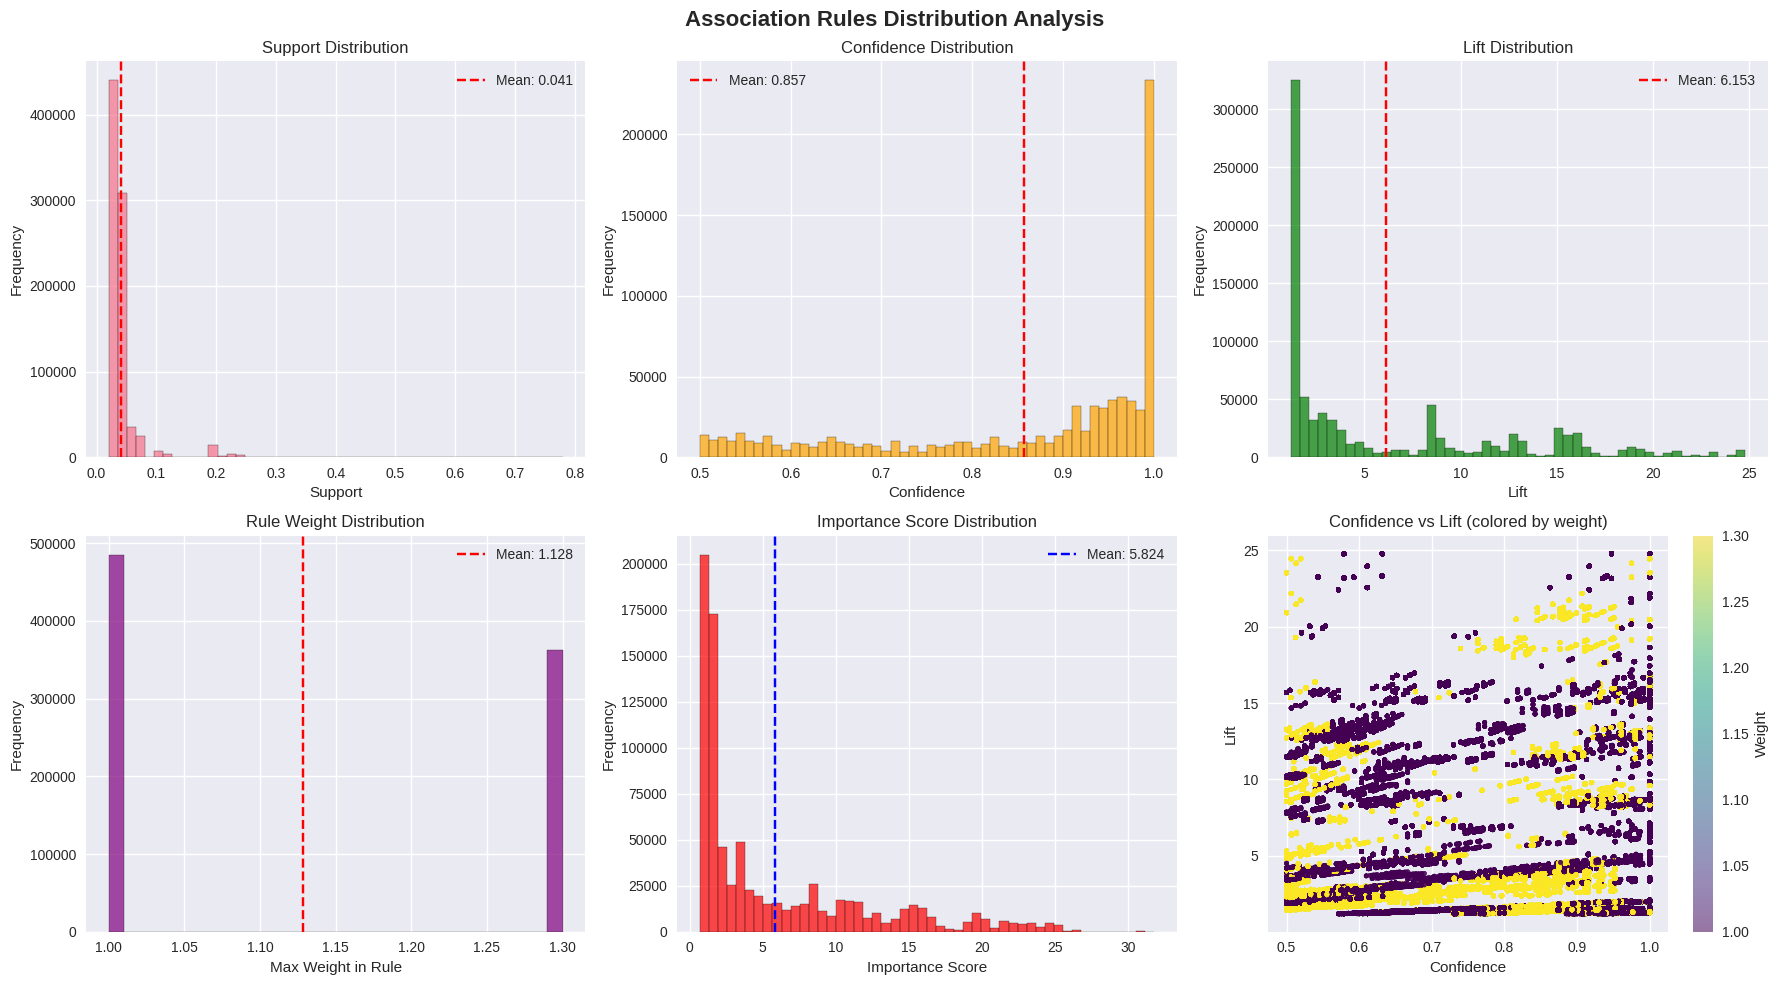


2. Creating top rules bar chart...
   Saved: top_rules_importance.png


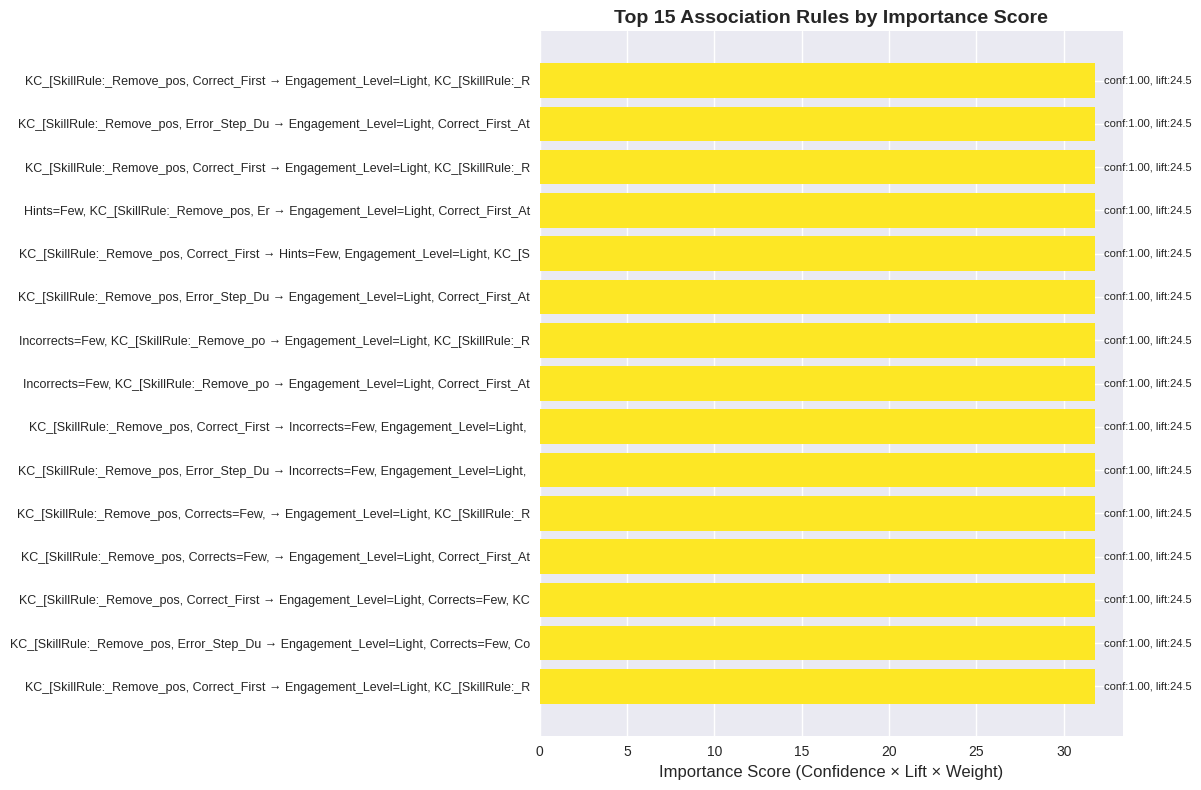


3. Analyzing rule complexity...
   Saved: rule_complexity.png


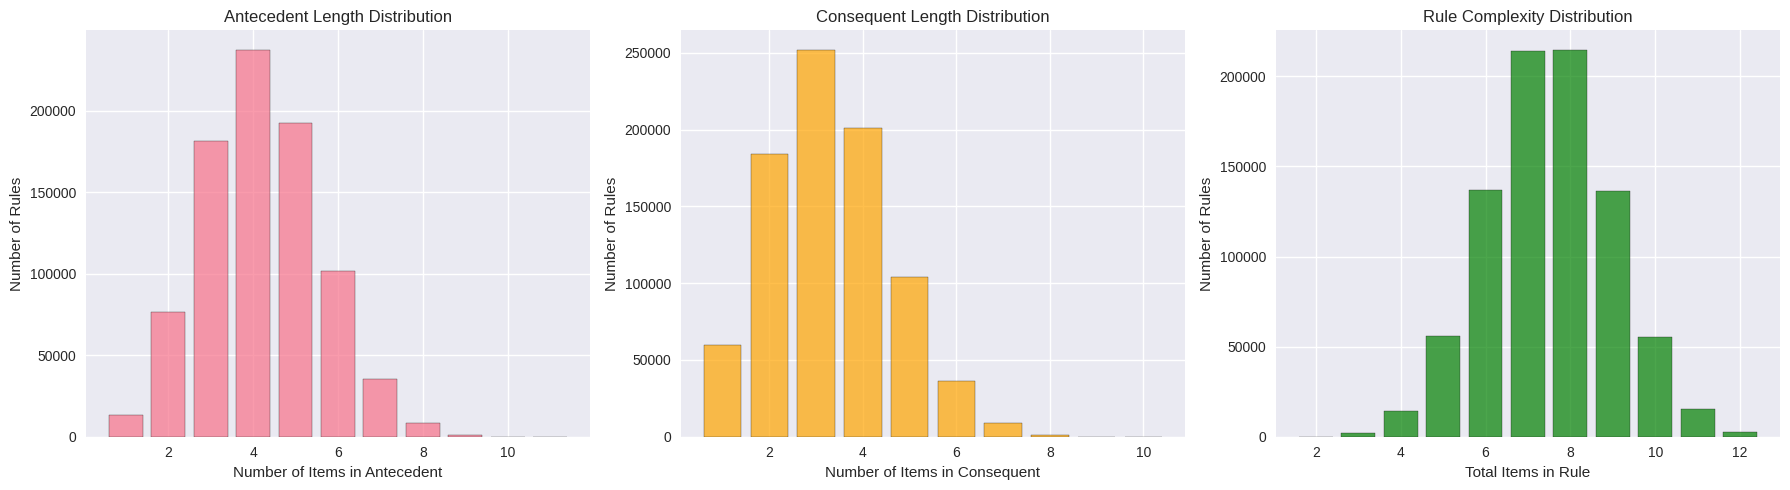


4. Analyzing most frequent items in rules...
   Saved: frequent_items_in_rules.png


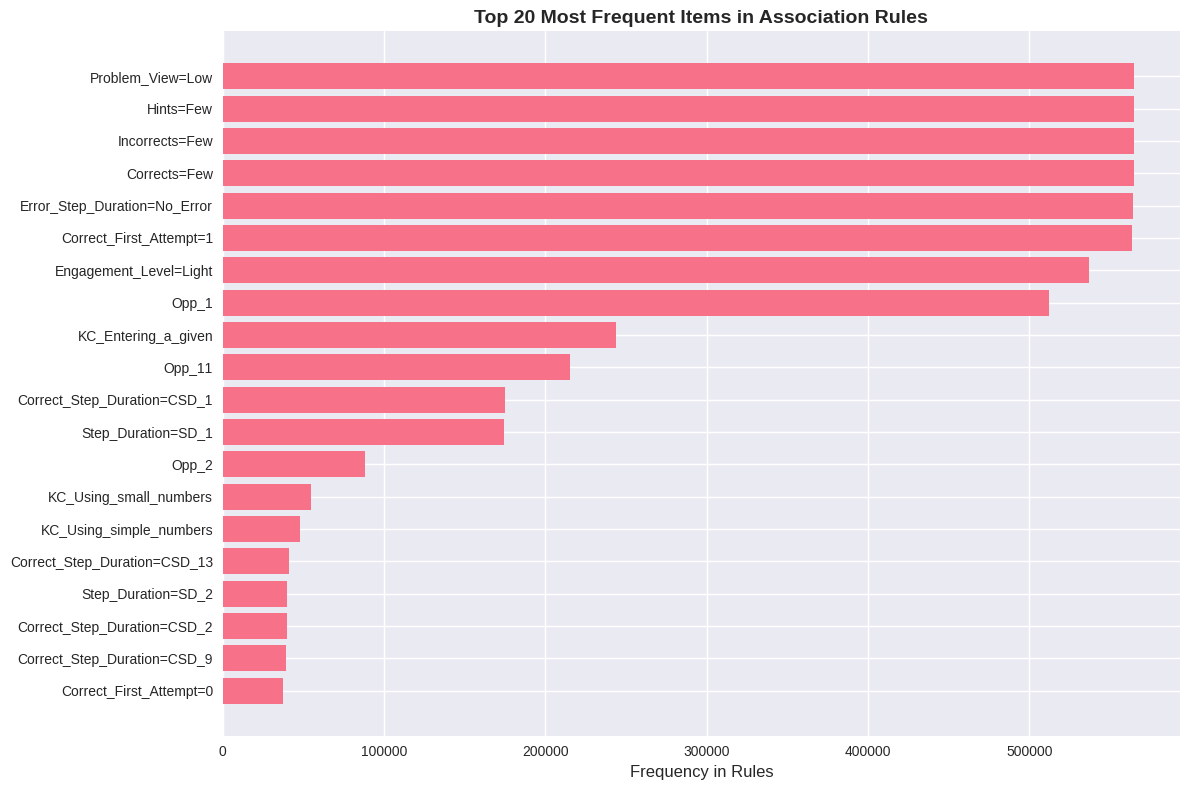


ALL VISUALIZATIONS COMPLETE

Generated files:
   - rule_distributions.png
   - top_rules_importance.png
   - rule_complexity.png
   - frequent_items_in_rules.png


In [ ]:
print("="*80)
print("VISUALIZING ASSOCIATION RULES")
print("="*80)

# ============================================================================
# 1. Rule Distribution Analysis
# ============================================================================
print("\n1. Creating rule distribution plots...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Association Rules Distribution Analysis', fontsize=16, fontweight='bold')

# Support distribution
axes[0, 0].hist(rules['support'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Support')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Support Distribution')
axes[0, 0].axvline(rules['support'].mean(), color='red', linestyle='--', label=f'Mean: {rules["support"].mean():.3f}')
axes[0, 0].legend()

# Confidence distribution
axes[0, 1].hist(rules['confidence'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Confidence')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Confidence Distribution')
axes[0, 1].axvline(rules['confidence'].mean(), color='red', linestyle='--', label=f'Mean: {rules["confidence"].mean():.3f}')
axes[0, 1].legend()

# Lift distribution
axes[0, 2].hist(rules['lift'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_xlabel('Lift')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Lift Distribution')
axes[0, 2].axvline(rules['lift'].mean(), color='red', linestyle='--', label=f'Mean: {rules["lift"].mean():.3f}')
axes[0, 2].legend()

# Weight distribution
axes[1, 0].hist(rules['rule_max_weight'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].set_xlabel('Max Weight in Rule')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Rule Weight Distribution')
axes[1, 0].axvline(rules['rule_max_weight'].mean(), color='red', linestyle='--', label=f'Mean: {rules["rule_max_weight"].mean():.3f}')
axes[1, 0].legend()

# Importance score distribution
axes[1, 1].hist(rules['importance_score'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 1].set_xlabel('Importance Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Importance Score Distribution')
axes[1, 1].axvline(rules['importance_score'].mean(), color='blue', linestyle='--', label=f'Mean: {rules["importance_score"].mean():.3f}')
axes[1, 1].legend()

# Scatter: Confidence vs Lift
scatter = axes[1, 2].scatter(rules['confidence'], rules['lift'],
                             c=rules['rule_max_weight'], cmap='viridis',
                             alpha=0.5, s=10)
axes[1, 2].set_xlabel('Confidence')
axes[1, 2].set_ylabel('Lift')
axes[1, 2].set_title('Confidence vs Lift (colored by weight)')
plt.colorbar(scatter, ax=axes[1, 2], label='Weight')

plt.tight_layout()
plt.savefig('./rule_distributions.png', dpi=300, bbox_inches='tight')
print("   Saved: rule_distributions.png")
plt.show()

# ============================================================================
# 2. Top Rules Visualization
# ============================================================================
print("\n2. Creating top rules bar chart...")

# Top 15 by importance score
top_rules = rules.nlargest(15, 'importance_score').copy()

# Create readable labels
def create_rule_label(row):
    ant = list(row['antecedents'])
    cons = list(row['consequents'])
    # Shorten for readability
    ant_short = ', '.join([a[:25] for a in ant])[:40]
    cons_short = ', '.join([c[:25] for c in cons])[:40]
    return f"{ant_short} → {cons_short}"

top_rules['rule_label'] = top_rules.apply(create_rule_label, axis=1)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top_rules)), top_rules['importance_score'],
               color=plt.cm.viridis(top_rules['rule_max_weight'] / top_rules['rule_max_weight'].max()))
ax.set_yticks(range(len(top_rules)))
ax.set_yticklabels(top_rules['rule_label'], fontsize=9)
ax.set_xlabel('Importance Score (Confidence × Lift × Weight)', fontsize=12)
ax.set_title('Top 15 Association Rules by Importance Score', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add confidence and lift annotations
for i, (idx, row) in enumerate(top_rules.iterrows()):
    ax.text(row['importance_score'] + 0.5, i,
            f"conf:{row['confidence']:.2f}, lift:{row['lift']:.1f}",
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig('./top_rules_importance.png', dpi=300, bbox_inches='tight')
print("   Saved: top_rules_importance.png")
plt.show()

# ============================================================================
# 3. Rule Length Analysis
# ============================================================================
print("\n3. Analyzing rule complexity...")

rules['antecedent_length'] = rules['antecedents'].apply(len)
rules['consequent_length'] = rules['consequents'].apply(len)
rules['total_items'] = rules['antecedent_length'] + rules['consequent_length']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Antecedent length
ant_counts = rules['antecedent_length'].value_counts().sort_index()
axes[0].bar(ant_counts.index, ant_counts.values, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Items in Antecedent')
axes[0].set_ylabel('Number of Rules')
axes[0].set_title('Antecedent Length Distribution')

# Consequent length
cons_counts = rules['consequent_length'].value_counts().sort_index()
axes[1].bar(cons_counts.index, cons_counts.values, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Number of Items in Consequent')
axes[1].set_ylabel('Number of Rules')
axes[1].set_title('Consequent Length Distribution')

# Total items
total_counts = rules['total_items'].value_counts().sort_index()
axes[2].bar(total_counts.index, total_counts.values, edgecolor='black', alpha=0.7, color='green')
axes[2].set_xlabel('Total Items in Rule')
axes[2].set_ylabel('Number of Rules')
axes[2].set_title('Rule Complexity Distribution')

plt.tight_layout()
plt.savefig('./rule_complexity.png', dpi=300, bbox_inches='tight')
print("   Saved: rule_complexity.png")
plt.show()

# ============================================================================
# 4. Item Frequency in Rules
# ============================================================================
print("\n4. Analyzing most frequent items in rules...")

# Count item appearances
from collections import Counter

all_items = []
for itemset in rules['antecedents']:
    all_items.extend(list(itemset))
for itemset in rules['consequents']:
    all_items.extend(list(itemset))

item_counts = Counter(all_items)
top_items = pd.DataFrame(item_counts.most_common(20), columns=['Item', 'Frequency'])

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top_items)), top_items['Frequency'])
ax.set_yticks(range(len(top_items)))
ax.set_yticklabels([item[:50] for item in top_items['Item']], fontsize=10)
ax.set_xlabel('Frequency in Rules', fontsize=12)
ax.set_title('Top 20 Most Frequent Items in Association Rules', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('./frequent_items_in_rules.png', dpi=300, bbox_inches='tight')
print("   Saved: frequent_items_in_rules.png")
plt.show()

print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETE")
print("="*80)
print("\nGenerated files:")
print("   - rule_distributions.png")
print("   - top_rules_importance.png")
print("   - rule_complexity.png")
print("   - frequent_items_in_rules.png")

##8. Intepretation of the results


## 1. **Rule Distributions (6-panel figure)**

### **Support Distribution (Top Left)**
- **What it shows:** How frequently itemsets appear together in transactions
- **Interpretation:**
  - **Heavily right-skewed** - most rules have very low support (0-0.1)
  - **Mean: 0.041 (4.1%)** - average rule covers only 4% of students
  - This is **expected** in educational data - specific learning patterns are diverse and individualized
  - The spike near 0 indicates many rare but potentially important patterns

### **Confidence Distribution (Top Middle)**
- **What it shows:** How often the consequent occurs when antecedent is present
- **Interpretation:**
  - **Mean: 0.857 (85.7%)** - very high! Rules are highly reliable
  - **Massive spike at 1.0** (perfect confidence) - many deterministic rules
  - Example: "IF Error_Step_Duration=No_Error → THEN Correct_First_Attempt=1" (100% confidence)
  - This suggests **strong causal relationships** in the data - certain conditions reliably predict outcomes

### **Lift Distribution (Top Right)**
- **What it shows:** How much more likely the consequent occurs with the antecedent vs. by chance
- **Interpretation:**
  - **Mean: 6.153** - items co-occur 6x more than random chance!
  - **Right-skewed with long tail** - some rules have lift >20
  - Values >1 indicate **positive correlation**, which all our rules have
  - High lift rules (15-25) represent **strong unexpected associations** - these are the most interesting discoveries

### **Weight Distribution (Bottom Left)**
- **What it shows:** Educational importance (max weight of items in each rule)
- **Interpretation:**
  - **Bimodal distribution** - two peaks at 1.0 and 1.3
  - **Mean: 1.128** - most rules involve low-weight items
  - **Weight 1.0 dominates** (500k+ rules) - these are common success patterns
  - **Weight 1.3 cluster** (360k rules) - rules involving KC items (default KC weight = 1.3)
  - **No weights ≥2.0** - struggle indicators (`Incorrects=Many`, `Hints=Many`) are too rare in filtered data

### **Importance Score Distribution (Bottom Middle)**
- **What it shows:** Combined metric: confidence × lift × weight
- **Interpretation:**
  - **Heavily right-skewed** - most rules have low importance (0-5)
  - **Mean: 5.824** - but some rules reach 30+!
  - **Long tail** indicates a few **exceptionally important rules** worth investigating
  - High-importance rules balance reliability, unexpectedness, and educational value

### **Confidence vs Lift Scatter (Bottom Right)**
- **What it shows:** Relationship between confidence and lift, colored by weight
- **Interpretation:**
  - **Positive correlation** - high confidence often means high lift
  - **Horizontal bands** - many rules cluster at specific lift values (5, 10, 15, 20)
  - **Yellow points (weight ~1.3)** scattered throughout - KC-involved rules at all confidence/lift levels
  - **Dense purple region** (weight 1.0) - common patterns dominate
  - Sweet spot: **top-right corner** (high confidence + high lift) = most valuable rules

---

## 2. **Top 15 Rules by Importance Score**

### **Key Pattern: All involve KC_[SkillRule:_Remove_positive_coefficient]**
- **What it shows:** Most important rules by combined metric
- **Interpretation:**
  - **Perfect confidence (1.00)** and **very high lift (24.5)** across all top rules
  - **All involve specific KC**: `Remove_positive_coefficient` - a critical algebra skill
  - **Common pattern:**
    ```
    IF {involving Remove_positive_coefficient KC}
    → THEN {Engagement_Level=Light, Correct_First_Attempt=1, No_Error}
    ```
  - **Educational insight:** Students who work on this particular skill tend to:
    - Have light engagement (early in course)
    - Get correct first attempts
    - Make no errors
  - **Hypothesis:** This KC might be an **early/introductory skill** that students master easily, or it's well-taught in the curriculum

---

## 3. **Rule Complexity (3-panel figure)**

### **Antecedent Length Distribution (Left)**
- **What it shows:** Number of conditions (IF items) per rule
- **Interpretation:**
  - **Peak at 4 items** (~240k rules)
  - **Range: 2-10 items** - most rules have 3-5 conditions
  - **Bell-shaped** - balanced complexity
  - Example: `IF Corrects=Few, Error_Duration=No_Error, Hints=Few, Opp_1`

### **Consequent Length Distribution (Middle)**
- **What it shows:** Number of predicted items (THEN items) per rule
- **Interpretation:**
  - **Peak at 4 items** (~250k rules) - similar to antecedent
  - **More concentrated** than antecedent distribution
  - Most rules predict **3-5 outcomes simultaneously**
  - Example: `THEN Correct_First_Attempt=1, Incorrects=Few, Engagement_Level=Light`

### **Total Rule Complexity (Right)**
- **What it shows:** Total items in rule (antecedent + consequent)
- **Interpretation:**
  - **Peaks at 7-8 items** (220k+ rules each)
  - **Range: 4-12 items** per rule
  - **Balanced distribution** - neither too simple nor too complex
  - This is ideal for interpretability - rules are detailed enough to be actionable but not overwhelming

---

## 4. **Most Frequent Items in Rules**

### **Top Items (in order):**

1. **Problem_View=Low** (~560k appearances)
   - Students mostly see problems 1-2 times (not revisiting)
   - Indicates first-time problem solving

2-7. **Success Indicators** (all ~555k appearances):
   - `Hints=Few`, `Incorrects=Few`, `Corrects=Few`
   - `Error_Step_Duration=No_Error`
   - `Correct_First_Attempt=1`
   - `Engagement_Level=Light`
   - **Pattern:** Most rules describe **successful student behavior**

8. **Opp_1** (~510k)
   - First opportunity to practice a KC
   - Many rules involve initial learning experiences

9. **KC_Entering_a_given** (~240k)
   - Most common knowledge component
   - Basic skill: entering given values from problem

10. **Opp_11** (~220k)
    - 11th practice opportunity
    - Rules track progression over multiple attempts

11-20. **Duration bins and other KCs**
   - `Step_Duration=SD_1` (fastest completion)
   - Various KC skills (`Using_small_numbers`, `Using_simple_numbers`)

### **Key Insights:**
- **Success patterns dominate** - most students succeed on most problems
- **Early opportunities emphasized** - Opp_1 is critical
- **Speed matters** - fastest durations (SD_1, CSD_1) appear frequently
- **Basic skills prevalent** - `Entering_a_given` is foundational

---

## **Overall Interpretation:**

### **What We Learned:**
1. **High-quality rules** - 85.7% average confidence with 6x lift shows strong patterns
2. **Specific KC importance** - `Remove_positive_coefficient` skill drives top rules
3. **Success-focused** - most patterns describe what successful students do
4. **Early learning critical** - first opportunities (Opp_1) heavily featured
5. **Balanced complexity** - 7-8 item rules are detailed yet interpretable

### **Actionable Insights for Educators:**
- Focus on **first opportunities** - they set the pattern
- **Remove_positive_coefficient** skill deserves attention in curriculum design
- Students who get **correct first attempts** tend to maintain success
- **Light engagement** early on isn't necessarily bad - might indicate efficiency

### **Limitations:**
- **No struggle patterns** found (weight ≥2.0) - rare items filtered out
- **Selection bias** - only top 20 problem hierarchies included
- **Temporal aspects** not fully captured - rules are cross-sectional

